# WEEK-04: Polynomial and Multiple Regression

Chirag Rao K V
AIML B 16
Reg: 240962180

In [ ]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [149]:
# create dummy dataset for linear regression
data = {
    "temp":[50,50,50,70,70,70,80,80,80,90,90,90,100,100,100],
    "yield":[3.3,2.8,2.9,2.3,2.6,2.1,2.5,2.9,2.4,3.0,3.1,2.8,3.3,3.5,3.0]
}
data = pd.DataFrame(data)
data

,temp,yield
0,50,3.3
1,50,2.8
2,50,2.9
3,70,2.3
4,70,2.6
5,70,2.1
6,80,2.5
7,80,2.9
8,80,2.4
9,90,3.0


/tmp/ipykernel_21662/3694994736.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


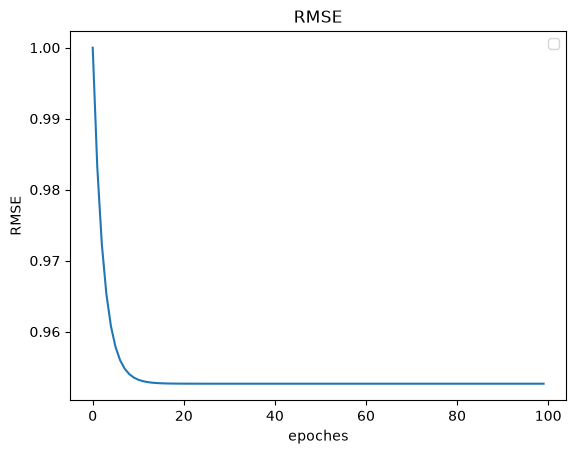

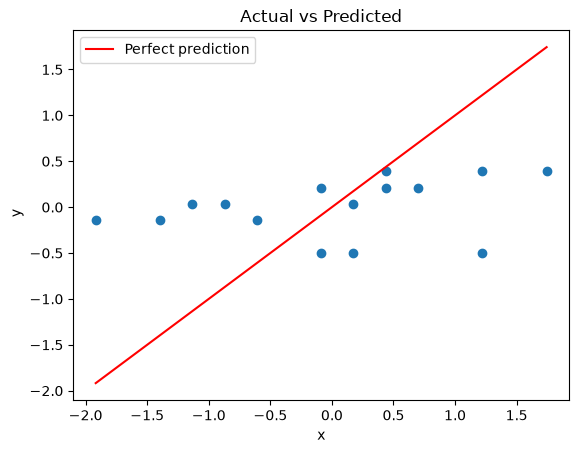

In [150]:
class Simple_LR:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)

        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def loss(self,pred,actual):
        self.loss_ = np.sqrt(np.mean((actual-pred)**2))
        return self.loss_

    def predict(self,x):
        return x @ self.weights + self.bias

    def train(self,no_epoch,alpha,norm_y=True):
        self.x = (self.x-np.mean(self.x,axis=0))/np.std(self.x,axis=0)
        if(norm_y):
            self.y = (self.y-np.mean(self.y))/np.std(self.y)
        self.loss_train = []

        for i in range(no_epoch):
            y_pred = self.x @ self.weights + self.bias
            dw = (-2 / len(self.x)) * (self.x.T @ (self.y - y_pred))
            db = (-2 / len(self.x)) * np.sum(self.y - y_pred)

            self.weights = self.weights - alpha * dw
            self.bias = self.bias - alpha * db
            self.loss_train.append(self.loss(y_pred,self.y))

        plt.plot(range(len(self.loss_train)), self.loss_train)

        plt.legend()
        plt.xlabel("epoches")
        plt.ylabel("RMSE")
        plt.show()

    def plot_data(self):
        y_pred = self.x @ self.weights + self.bias

        plt.scatter(self.y, y_pred)
        plt.xlabel("x")
        plt.ylabel(" y")
        plt.title("Actual vs Predicted")
        
        # Perfect prediction line
        min_val = min(self.y.min(), y_pred.min())
        max_val = max(self.y.max(), y_pred.max())
        plt.plot([min_val, max_val],
                [min_val, max_val],
                color="red",
                label="Perfect prediction")

        plt.legend()
        plt.show()
LR = Simple_LR(data['temp'].to_numpy(),data['yield'].to_numpy())
plt.title("RMSE")
LR.train(100,0.1)
LR.plot_data()

In [151]:
class Poly_Reg:
    def __init__(self, poly):
        self.poly = poly
        self.w = np.zeros(poly)
        self.b = 0

    def predict(self, x):
        x = np.array(x)
        powers = np.arange(1, self.poly + 1)
        x_poly = x[:, np.newaxis] ** powers
        return np.dot(x_poly, self.w) + self.b
    
    def get_rmse(self, error):
        return np.sqrt(np.mean(error**2))
    
    def fit(self, x, y, lr=0.01, epochs=1000):
        x = (x- np.mean(x))/np.std(x)
        y = (y- np.mean(y))/np.std(y)
        m = len(x)
        self.error_ = []
        self.rmse = []

        for _ in tqdm(range(epochs)):
            y_pred = self.predict(x)
            error = y_pred - y
            self.error_.append(np.mean(error))
            self.rmse.append(self.get_rmse(error))
            dw = np.zeros(self.poly)
            for i in range(self.poly):
                dw[i] = (2 / m) * np.sum(error * x**(i + 1))
            db = (2 / m) * np.sum(error)
            self.w -= lr * dw
            self.b -= lr * db
        plt.plot(range(len(self.error_)), self.error_)
        plt.legend()
        plt.xlabel("epoches")
        plt.ylabel("Error")
        plt.show()
        plt.plot(range(len(self.rmse)), self.rmse)
        plt.legend()
        plt.xlabel("epoches")
        plt.ylabel("RMSE")
        plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 1540.51it/s]
/tmp/ipykernel_21662/3719414294.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


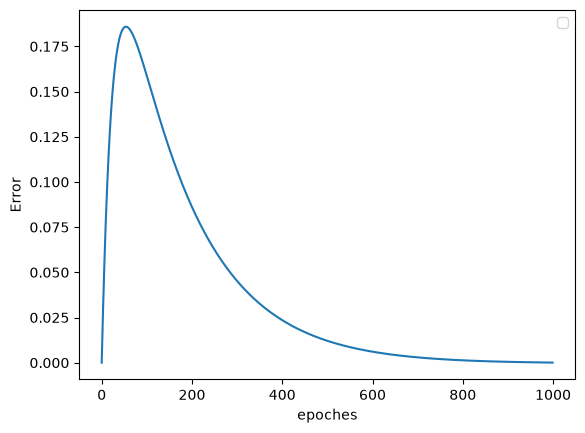

/tmp/ipykernel_21662/3719414294.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


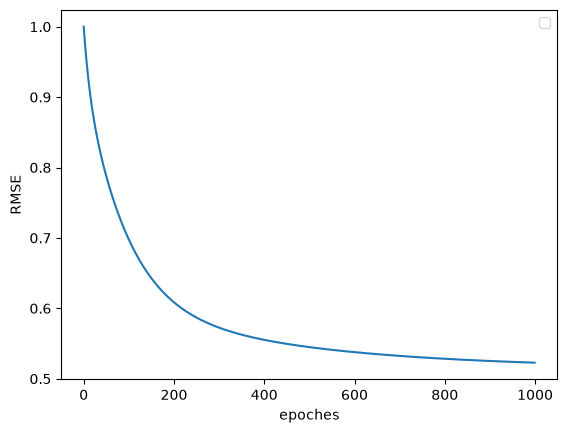

In [152]:
pr = Poly_Reg(3)
pr.fit(data["temp"],data["yield"],0.01,epochs=1000)

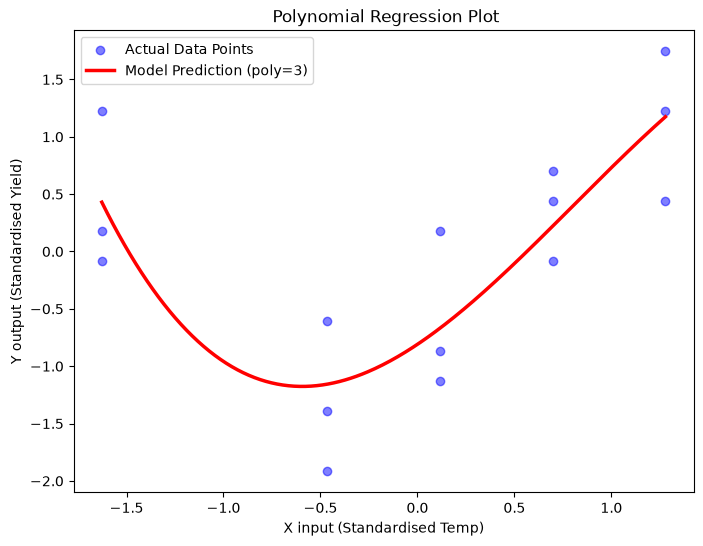

In [153]:
x = data["temp"].to_numpy()
y = data["yield"].to_numpy()

x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)  

x_smooth = np.linspace(x.min(), x.max(), 300)
y_pred_smooth = pr.predict(x_smooth)  # Predict on the smooth range

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color="blue", alpha=0.5, label="Actual Data Points")

plt.plot(
    x_smooth, 
    y_pred_smooth, 
    color="red",
    linewidth=2.5,
    label=f"Model Prediction (poly={pr.poly})",
)

plt.title(" Polynomial Regression Plot")
plt.xlabel("X input (Standardised Temp)")
plt.ylabel("Y output (Standardised Yield)")
plt.legend()
plt.show()


In [154]:
n = len(x)
numerator = np.sum((x - np.mean(x)) * (y - np.mean(y)))
denominator = np.sum((x - np.mean(x)) ** 2)

a = numerator / denominator
b = np.mean(y) - (a * np.mean(x))

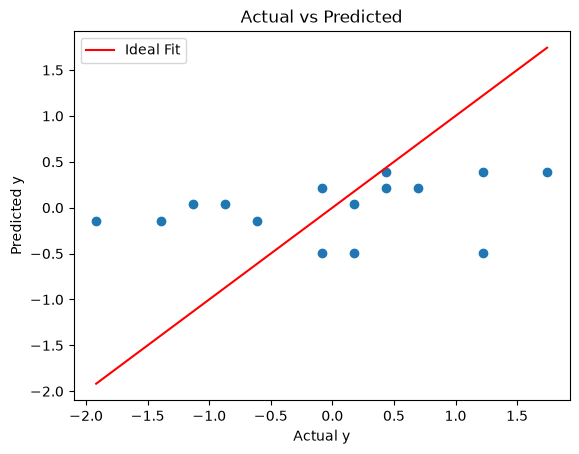

In [155]:
# Calculate predicted y values
y_pred = (a * x) + b
plt.scatter(y,y_pred)
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', label='Ideal Fit')
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

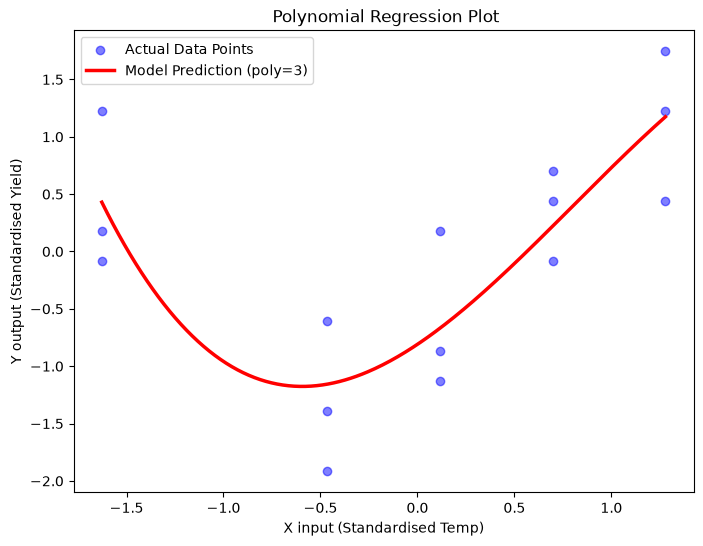

In [156]:

A = np.array([[len(x), x.sum(), (x**2).sum()], [x.sum(), (x**2).sum(), (x**3).sum()], [(x**2).sum(), (x**3).sum(), (x**4).sum()]], float)
C = np.array([y.sum(), (x * y).sum(), ((x**2) * y).sum()], float)
a0, a1, a2 = np.linalg.solve(A, C)
y_pred = a0 + a1 * x + a2 * x**2
x_smooth = np.linspace(x.min(), x.max(), 300)
y_pred_smooth = pr.predict(x_smooth)  
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color="blue", alpha=0.5, label="Actual Data Points")
plt.plot(
    x_smooth, 
    y_pred_smooth, 
    color="red",
    linewidth=2.5,
    label=f"Model Prediction (poly={pr.poly})",
)
plt.title(" Polynomial Regression Plot")
plt.xlabel("X input (Standardised Temp)")
plt.ylabel("Y output (Standardised Yield)")
plt.legend()
plt.show()

In [ ]:
 print(f"{'Method':<30}|{'a0':<15} | {'a1 ':<15} | {'a2':<15}")
print("-" * 99)
print(f"{'Manual Matrix':<30} | {a0:<15.6f} | {a1:<15.6f} | {a2:<15.6f}")
print(f"{'Program':<30} | {pr.w[2]:<15.6f} | {pr.w[1]:<15.6f} | {pr.w[0]:<15.6f}")

Method                        |a0              | a1              | a2             
---------------------------------------------------------------------------------------------------
Manual Matrix                  | -0.832600       | 0.633604        | 0.832600       
Program                        | -0.287665       | 0.695425        | 1.132293       


## Q2

Fitted Coefficients (b0, b1, b2, b3):
  b0 (Intercept): -0.1345
  b1 (Region at Risk): 0.6127
  b2 (Early Cooling): -0.2435
  b3 (Late Cooling): -0.0657
Intuitive (np.linalg.lstsq)    | -0.134536       | 0.612655        | -0.243482       | -0.065656      

Model Evaluation:
  MSE: 0.0195
  RMSE: 0.1395


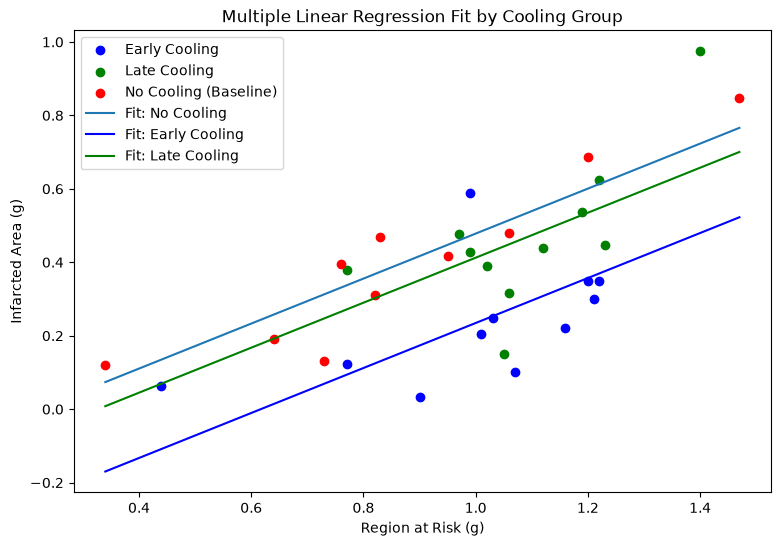

In [158]:
df = pd.read_csv("heart_attack_data.csv")
X = np.column_stack([np.ones(len(df)), df['Region_At_Risk'], df['x2'], df['x3']])
y = df['Infarc_Area'].values
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print("Fitted Coefficients (b0, b1, b2, b3):")
print(f"  b0 (Intercept): {beta[0]:.4f}")
print(f"  b1 (Region at Risk): {beta[1]:.4f}")
print(f"  b2 (Early Cooling): {beta[2]:.4f}")
print(f"  b3 (Late Cooling): {beta[3]:.4f}")
y_pred = X @ beta
residuals = y - y_pred
n = len(y)
p = X.shape[1]
print(f"{'Intuitive (np.linalg.lstsq)':<30} | {beta_intuitive[0]:<15.6f} | {beta_intuitive[1]:<15.6f} | {beta_intuitive[2]:<15.6f} | {beta_intuitive[3]:<15.6f}")

mse = np.sum(residuals**2) / (n - p)
rmse = np.sqrt(mse)
print(f"\nModel Evaluation:")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
plt.figure(figsize=(9, 6))
colors = {3: 'red', 1: 'blue', 2: 'green'}
labels = {3: 'No Cooling (Baseline)', 1: 'Early Cooling', 2: 'Late Cooling'}
for grp in [1, 2, 3]:
    subset = df[df['Group'] == grp]
    plt.scatter(subset['Region_At_Risk'], subset['Infarc_Area'], label=labels[grp], color=colors[grp])

x_range = np.linspace(df['Region_At_Risk'].min(), df['Region_At_Risk'].max(), 100)
plt.plot(x_range, beta[0] + beta[1]*x_range, label='Fit: No Cooling')
plt.plot(x_range, beta[0] + beta[1]*x_range + beta[2], color='blue', label='Fit: Early Cooling')
plt.plot(x_range, beta[0] + beta[1]*x_range + beta[3], color='green', label='Fit: Late Cooling')

plt.xlabel('Region at Risk (g)')
plt.ylabel('Infarcted Area (g)')
plt.title('Multiple Linear Regression Fit by Cooling Group')
plt.legend()
plt.show()

In [159]:
import numpy as np
import pandas as pd
df = pd.read_csv('heart_attack_data.csv')
X = np.column_stack([np.ones(len(df)), df['Region_At_Risk'], df['x2'], df['x3']])
y = df['Infarc_Area'].values
beta_matrix = np.linalg.inv(X.T @ X) @ X.T @ y
beta_intuitive = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"{'Method':<30} | {'b0 (Intercept)':<15} | {'b1 (Risk)':<15} | {'b2 (Early)':<15} | {'b3 (Late)':<15}")
print("-" * 99)
print(f"{'Manual Matrix (X^T X)^-1 X^T y':<30} | {beta_matrix[0]:<15.6f} | {beta_matrix[1]:<15.6f} | {beta_matrix[2]:<15.6f} | {beta_matrix[3]:<15.6f}")
print(f"{'Intuitive (np.linalg.lstsq)':<30} | {beta_intuitive[0]:<15.6f} | {beta_intuitive[1]:<15.6f} | {beta_intuitive[2]:<15.6f} | {beta_intuitive[3]:<15.6f}")
print(f"{'Program':<30} | {beta[0]:<15.6f} | {beta[1]:<15.6f} | {beta[2]:<15.6f} | {beta[3]:<15.6f}")


Method                         | b0 (Intercept)  | b1 (Risk)       | b2 (Early)      | b3 (Late)      
---------------------------------------------------------------------------------------------------
Manual Matrix (X^T X)^-1 X^T y | -0.134536       | 0.612655        | -0.243482       | -0.065656      
Intuitive (np.linalg.lstsq)    | -0.134536       | 0.612655        | -0.243482       | -0.065656      
Program                        | -0.134536       | 0.612655        | -0.243482       | -0.065656      
